In [ ]:
import re
import numpy as np
import pandas as pd
import pandas as pd
import re

In [ ]:
from match_game_roles import get_role_config
from extract_game_events import extract_game_events
from compute_measures import run

match_list=['E:\\GaTech\\Research Projects\\werewolf\\Data\\Game1_TEST.csv',
            'E:\\GaTech\\Research Projects\\werewolf\\Data\\Game2_BV1MMPxzmEps.csv',
            'E:\\GaTech\\Research Projects\\werewolf\\Data\\Game3_BV1juPwzfEj5.csv',
            'E:\\GaTech\\Research Projects\\werewolf\\Data\\Game4_BV1ZGwAzZEny.csv']
ROLE_INFO = 'E:\\GaTech\\Research Projects\\werewolf\\Data\\Game_Role_Info.csv'

for CSV in match_list:
    OUT = f'E:\\GaTech\\Research Projects\\werewolf\\Data\\game{match_list.index(CSV)+1}_core_measures_verbose.csv'
    P_COLS = [f"player {i}" for i in range(1, 13)]

    df = pd.read_csv(CSV)
    cfg = get_role_config(CSV, ROLE_INFO)
    timeline = extract_game_events(df, P_COLS)

    #print(timeline)

    result = run(df=df,cfg=cfg,timeline=timeline,player_cols=P_COLS, output_csv=OUT, verbose=True )

    print("\n\n=== 各玩家平均核心指标 ===")
    print(result.groupby(["speaker", "role", "camp"])[["L_consistency", "self_pressure", "role_ambiguity", "public_conflict"]].mean().round(3).to_string()  )

本局游戏身份（上帝视角）
     1号  混血儿    (神营)
  ★  2号  狼人     (狼营)
     3号  平民     (民营)
     4号  平民     (民营)
     5号  女巫     (神营)
  ★  6号  狼人     (狼营)
     7号  预言家    (神营)
     8号  平民     (民营)
     9号  白神     (神营)
  ★ 10号  狼人     (狼营)
  ★ 11号  狼人     (狼营)
    12号  猎人     (神营)

  混血儿: 1号，榜样: 5号(女巫)


────────────────────────────────────────────────────────────
【第 1 夜】
  夜间行动：
    1号(混血儿) 混 5号(女巫) → 好人混
    2号(狼人) 刀 5号(女巫)
    5号(女巫) 首刀目标
    5号(女巫) 毒 4号(平民)
    6号(狼人) 刀 5号(女巫)
    7号(预言家) 验 8号(平民) → 金水
    10号(狼人) 刀 5号(女巫)
    11号(狼人) 刀 5号(女巫)

  上警环节  玩家: [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12]
  天亮

  玩家 3号（平民/民）  [L_cons=0.00  pressure=0.00  role_amb=1.00  pub_conf=0.00]
    core: L_cons=0.00  pressure=0.00  role_amb=1.00  pub_conf=0.00

  玩家 4号（平民/民）  [L_cons=0.00  pressure=0.00  role_amb=1.00  pub_conf=0.00]
    core: L_cons=0.00  pressure=0.00  role_amb=1.00  pub_conf=0.00

  玩家 5号（女巫/神）  [L_cons=0.00  pressure=0.00  role_amb=1.00  pub_conf=0.00]
    core: L_cons=0.00  pressure=0.00  role_amb=1.0

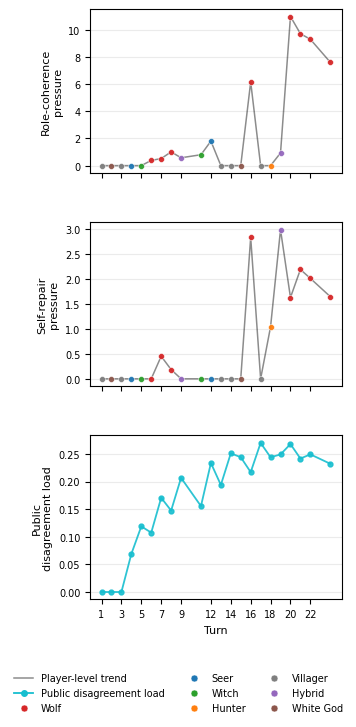

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df = pd.read_csv(r"E:\GaTech\Research Projects\werewolf\Data\game3_core_measures_verbose.csv",encoding="utf-8-sig").sort_values("turn").copy()

df = df.rename(columns={"L_consistency": "role_coherence_pressure","self_pressure": "self_repair_pressure","public_conflict": "public_disagreement_load"})

role_map = {"狼人": "Wolf",
    "预言家": "Seer",
    "女巫": "Witch",
    "猎人": "Hunter",
    "平民": "Villager",
    "混血儿": "Hybrid",
    "白神": "White God",
    "好人": "Good",
}
df["role_en"] = df["role"].replace(role_map)

role_colors = {
    "Wolf": "tab:red",
    "Seer": "tab:blue",
    "Witch": "tab:green",
    "Hunter": "tab:orange",
    "Villager": "tab:gray",
    "Hybrid": "tab:purple",
    "White God": "tab:brown",
    "Good": "tab:olive",
}

role_order = ["Wolf", "Seer", "Witch", "Hunter", "Villager", "Hybrid", "White God", "Good"]

fig, axes = plt.subplots(nrows=3, ncols=1,figsize=(3.4, 7.2),sharex=True)


ax = axes[0]
ax.plot(df["turn"],df["role_coherence_pressure"],color="black",alpha=0.45,linewidth=1.1,zorder=1)

for role in role_order:
    sub = df[df["role_en"] == role]
    if sub.empty:
        continue
    ax.scatter(sub["turn"],sub["role_coherence_pressure"],color=role_colors.get(role, "black"),s=18,alpha=0.95,edgecolor="white",linewidth=0.35,zorder=2)

ax.set_ylabel("Role-coherence\npressure", fontsize=8)
ax.grid(True, axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.tick_params(axis="both", labelsize=7)

ax = axes[1]
ax.plot(df["turn"],df["self_repair_pressure"],color="black",alpha=0.45,linewidth=1.1,zorder=1)

for role in role_order:
    sub = df[df["role_en"] == role]
    if sub.empty:
        continue
    ax.scatter(sub["turn"],sub["self_repair_pressure"],color=role_colors.get(role, "black"),s=18, alpha=0.95,edgecolor="white",linewidth=0.35,zorder=2)

ax.set_ylabel("Self-repair\npressure", fontsize=8)
ax.grid(True, axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.tick_params(axis="both", labelsize=7)

ax = axes[2]


turn_level = (df[["turn", "public_disagreement_load"]].drop_duplicates(subset=["turn"]).sort_values("turn"))

ax.plot(turn_level["turn"],turn_level["public_disagreement_load"],color="tab:cyan",alpha=0.9,linewidth=1.3,marker="o",markersize=3.5,zorder=2)

ax.set_ylabel("Public\ndisagreement load", fontsize=8)
ax.grid(True, axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.tick_params(axis="both", labelsize=7)


unique_turns = sorted(df["turn"].unique())
if len(unique_turns) > 15:
    axes[-1].set_xticks(unique_turns[::2])
else:
    axes[-1].set_xticks(unique_turns)

axes[-1].set_xlabel("Turn", fontsize=8)


role_handles = []
for role in role_order:
    if role not in df["role_en"].values:
        continue
    role_handles.append(
        Line2D([0], [0],marker="o",color="w",markerfacecolor=role_colors.get(role, "black"),markeredgecolor="white",markeredgewidth=0.35,markersize=5,label=role))

trend_handle = Line2D([0], [0],color="black",alpha=0.45,linewidth=1.1,label="Player-level trend")

public_handle = Line2D([0], [0],color="tab:cyan",linewidth=1.3,marker="o",markersize=4,label="Public disagreement load")

fig.legend(handles=[trend_handle, public_handle] + role_handles,
    loc="lower center",bbox_to_anchor=(0.5, -0.01),ncol=3,frameon=False,fontsize=7)

plt.subplots_adjust(left=0.24,right=0.98,top=0.98,bottom=0.16,hspace=0.30)
plt.savefig(r"E:\GaTech\Research Projects\werewolf\Data\game3_core_measures_plot.png", dpi=300)
plt.show()
